Main Dataset Shape  : (5000, 23)
Target Dataset Shape: (5000, 3)
Merged Dataset Shape: (5000, 25)

Missing values after imputation:
None ✅

Target column: placement_status_Placed
Class distribution:
 placement_status_Placed
1    4303
0     697
Name: count, dtype: int64

Feature count: 28

Train samples: 4000 | Test samples: 1000

🔹 K-Nearest Neighbours Classifier (k=5)
Accuracy : 0.8650  (86.50%)
Precision: 0.8742
Recall   : 0.9849
F1-Score : 0.9263

🔹 Decision Tree Classifier
Accuracy : 0.8460  (84.60%)
Precision: 0.9031
Recall   : 0.9199
F1-Score : 0.9114

🔹 K-Means Clustering (k=2)
Cluster-to-label mapping accuracy: 0.8606  (86.06%)

📊 FINAL RESULTS
        Model  Accuracy Precision    Recall  F1 Score
    KNN (k=5)    0.8650  0.874227  0.984901   0.92627
Decision Tree    0.8460  0.903079  0.919861  0.911392
K-Means (k=2)    0.8606       N/A       N/A       N/A


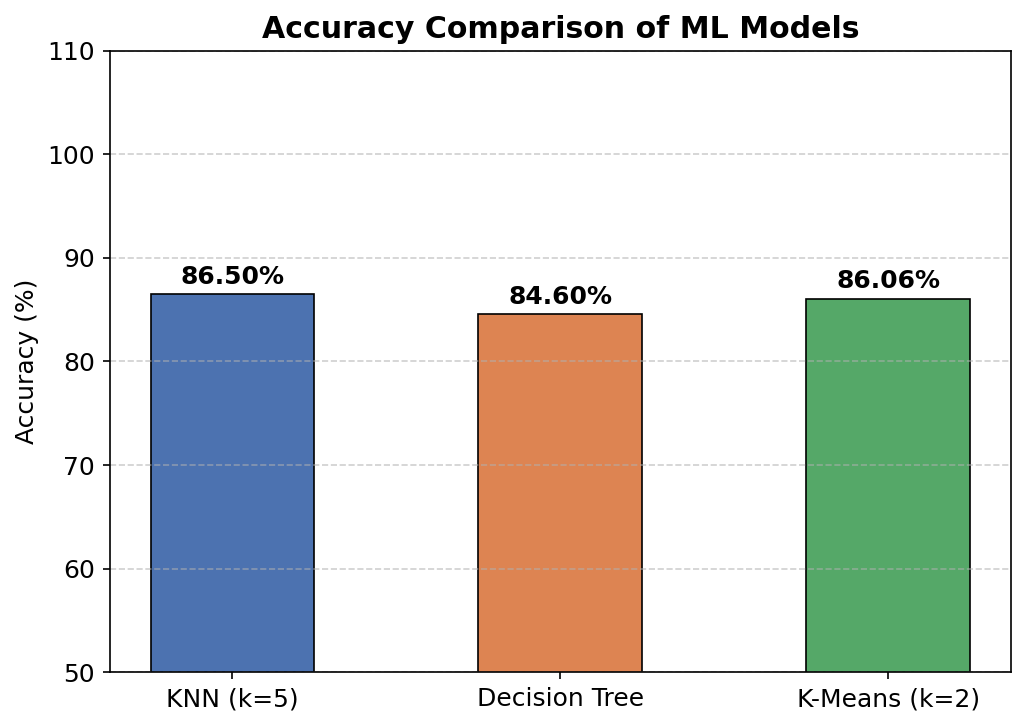

✅ Graph 1 saved


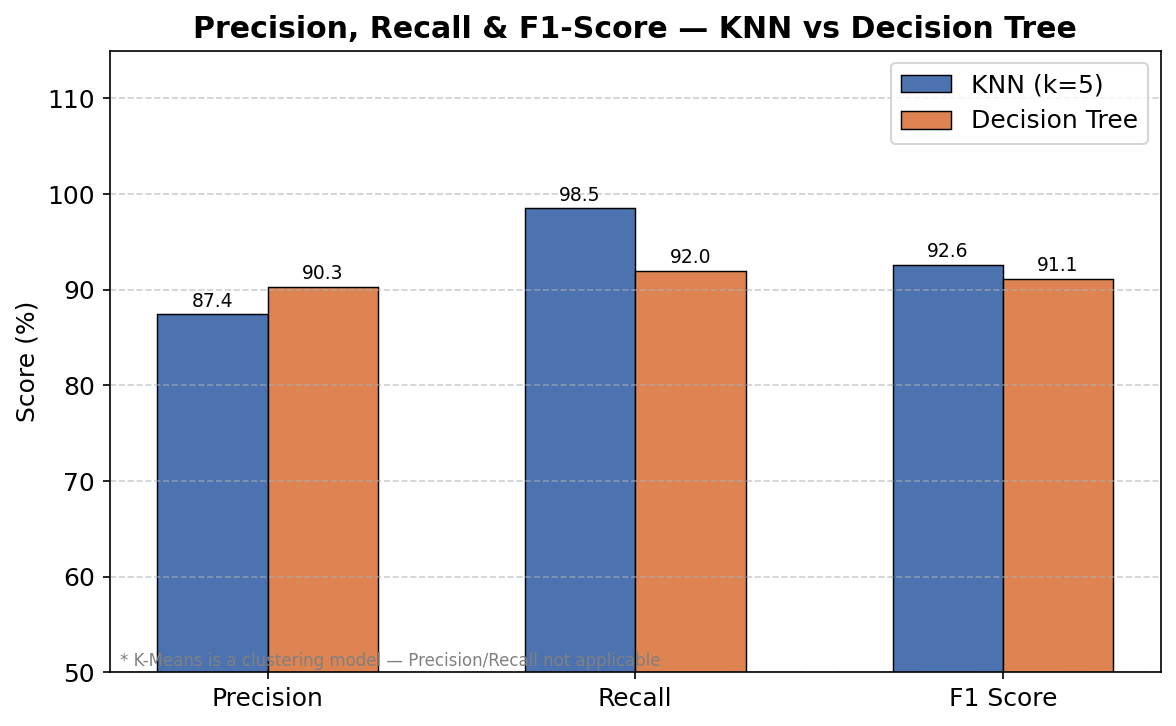

✅ Graph 2 saved


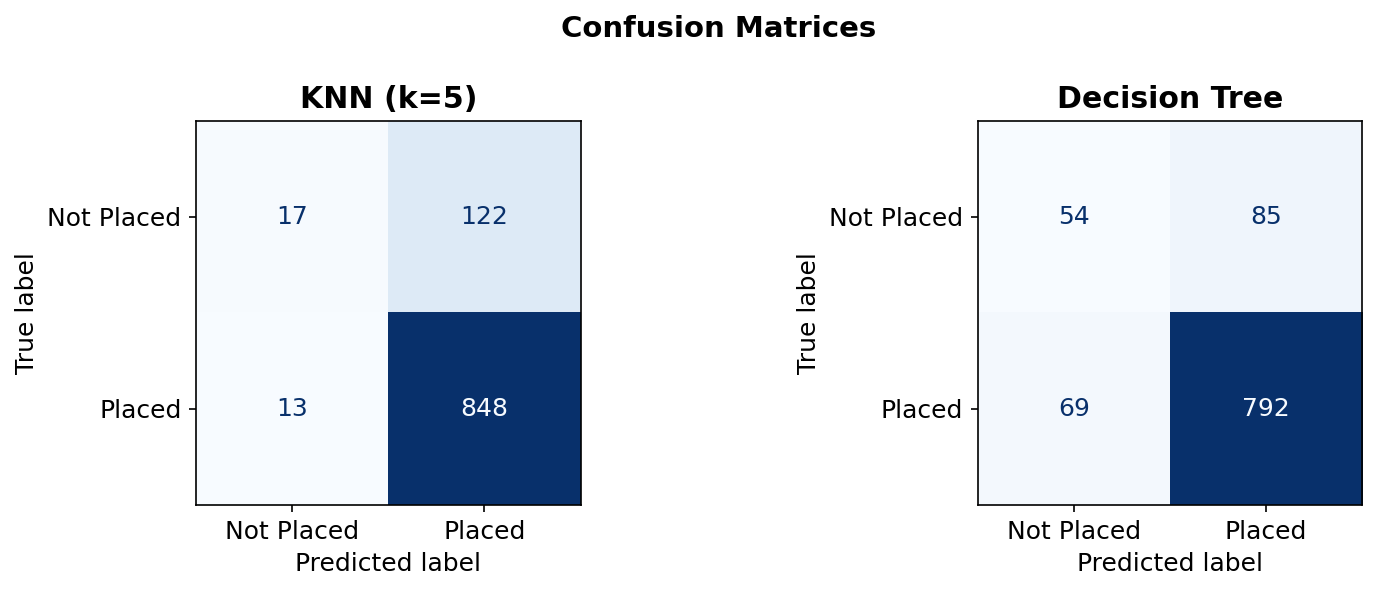

✅ Graph 3 saved


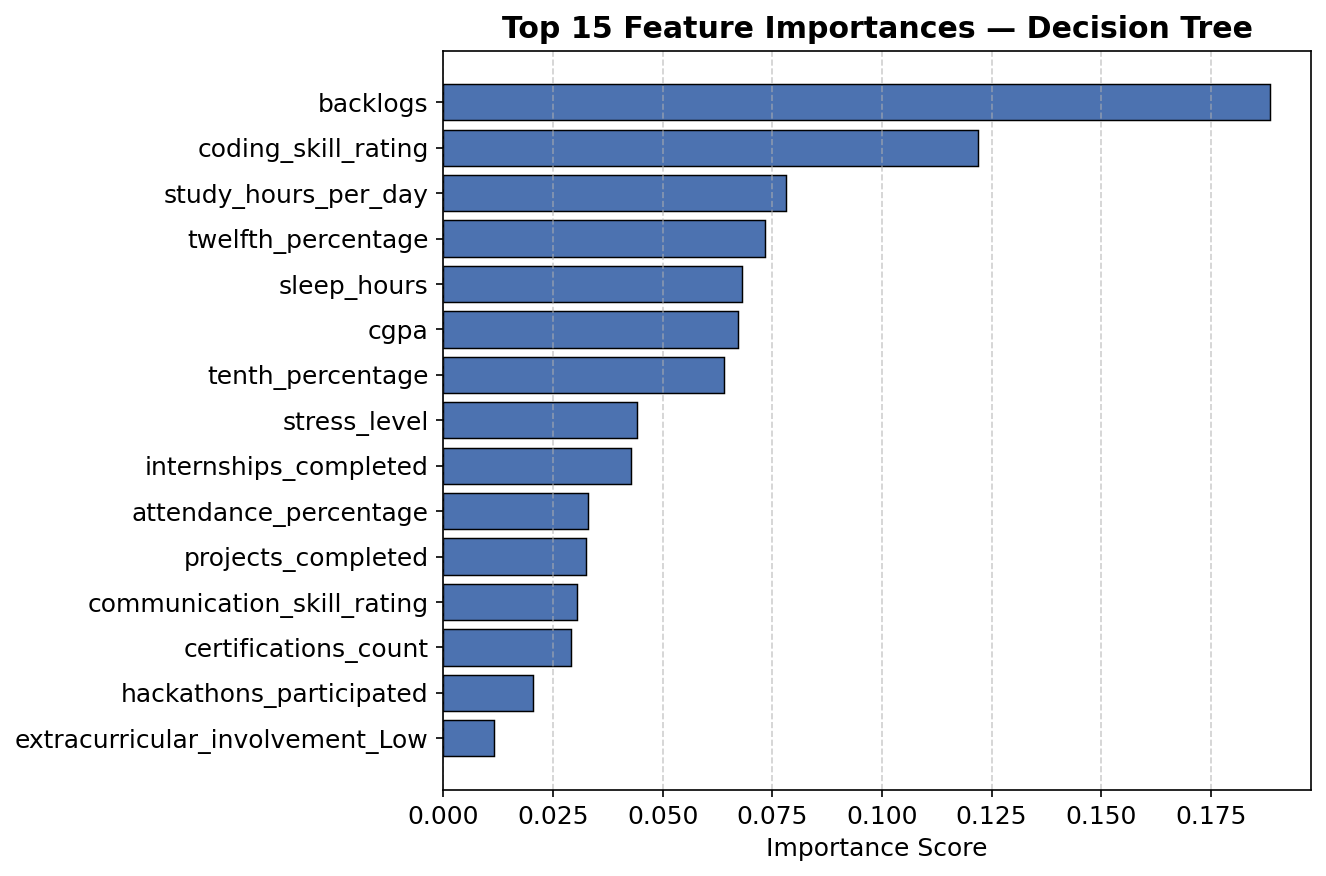

✅ Graph 4 saved


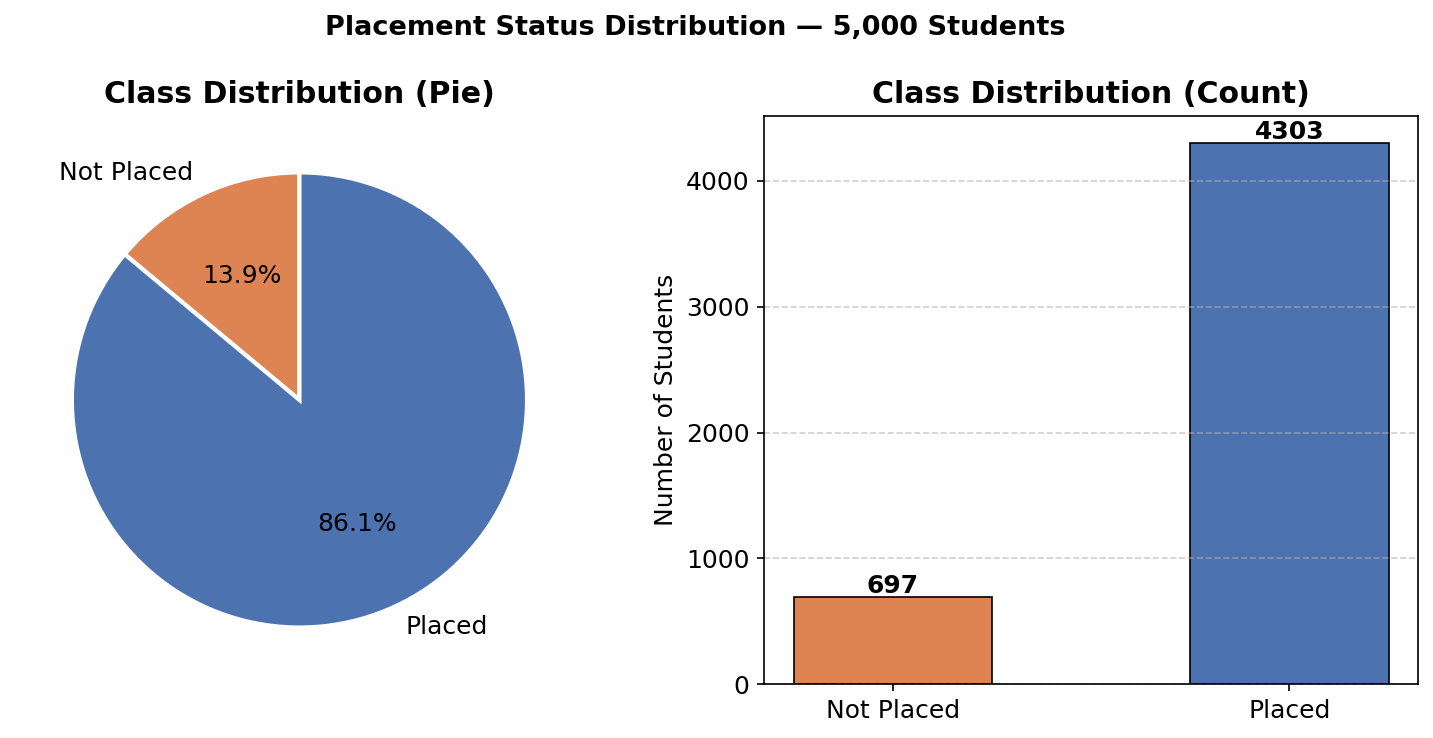

✅ Graph 5 saved


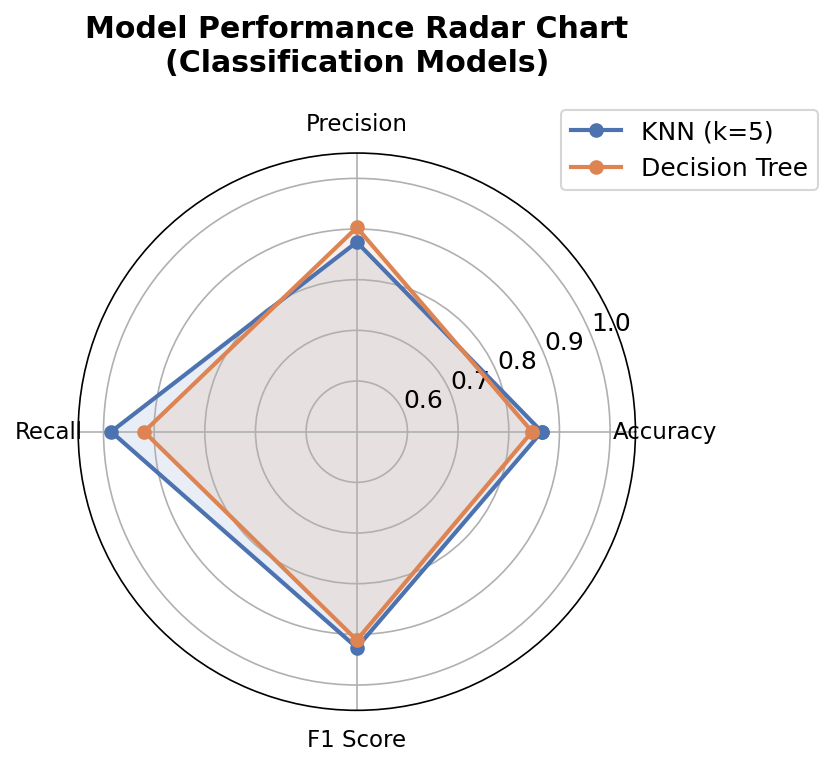

✅ Graph 6 saved


In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from scipy.stats import mode

plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})
COLORS = ['#4C72B0', '#DD8452', '#55A868']


df_features = pd.read_csv("indian_engineering_student_placement.csv")
df_labels   = pd.read_csv("placement_targets.csv")

print("Main Dataset Shape  :", df_features.shape)
print("Target Dataset Shape:", df_labels.shape)

df = pd.merge(df_features, df_labels, on='Student_ID', how='inner')
print("Merged Dataset Shape:", df.shape)



df.drop(['Student_ID', 'salary_lpa'], axis=1, inplace=True)

df['extracurricular_involvement'].fillna(
    df['extracurricular_involvement'].mode()[0], inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else "None ✅")

df = pd.get_dummies(df, drop_first=True)

target_col = [c for c in df.columns if 'placement_status' in c][0]
print("\nTarget column:", target_col)

X = df.drop(target_col, axis=1)
y = df[target_col].astype(int)

print("Class distribution:\n", y.value_counts())
print("\nFeature count:", X.shape[1])

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")


print("\n" + "="*55)
print("🔹 K-Nearest Neighbours Classifier (k=5)")
print("="*55)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

acc_knn  = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn  = recall_score(y_test, y_pred_knn)
f1_knn   = f1_score(y_test, y_pred_knn)

print(f"Accuracy : {acc_knn:.4f}  ({acc_knn*100:.2f}%)")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall   : {rec_knn:.4f}")
print(f"F1-Score : {f1_knn:.4f}")

print("\n" + "="*55)
print("🔹 Decision Tree Classifier")
print("="*55)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)

print(f"Accuracy : {acc_dt:.4f}  ({acc_dt*100:.2f}%)")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall   : {rec_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")

print("\n" + "="*55)
print("🔹 K-Means Clustering (k=2)")
print("="*55)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_scaled)           # fit on full scaled data
cluster_labels = kmeans.labels_

y_all = y.values
mapped = np.zeros_like(cluster_labels)
for cluster_id in range(2):
    mask         = (cluster_labels == cluster_id)
    majority     = mode(y_all[mask], keepdims=True).mode[0]
    mapped[mask] = majority

acc_km = accuracy_score(y_all, mapped)
print(f"Cluster-to-label mapping accuracy: {acc_km:.4f}  ({acc_km*100:.2f}%)")

results = pd.DataFrame({
    "Model"    : ["KNN (k=5)", "Decision Tree", "K-Means (k=2)"],
    "Accuracy" : [acc_knn,     acc_dt,           acc_km],
    "Precision": [prec_knn,    prec_dt,           "N/A"],
    "Recall"   : [rec_knn,     rec_dt,            "N/A"],
    "F1 Score" : [f1_knn,      f1_dt,             "N/A"],
})
print("\n" + "="*55)
print("📊 FINAL RESULTS")
print("="*55)
print(results.to_string(index=False))


fig, ax = plt.subplots(figsize=(7, 5))
models  = ["KNN (k=5)", "Decision Tree", "K-Means (k=2)"]
accs    = [acc_knn * 100, acc_dt * 100, acc_km * 100]
bars    = ax.bar(models, accs, color=COLORS, width=0.5,
                 edgecolor='black', linewidth=0.8)
ax.set_ylim(50, 110)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy Comparison of ML Models", fontweight='bold')
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.2f}%", ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("graph1_accuracy_comparison.png", bbox_inches='tight')
plt.show()

metrics     = ['Precision', 'Recall', 'F1 Score']
knn_vals    = [prec_knn * 100, rec_knn * 100, f1_knn * 100]
dt_vals     = [prec_dt  * 100, rec_dt  * 100, f1_dt  * 100]
x           = np.arange(len(metrics))
width       = 0.30

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, knn_vals, width, label='KNN (k=5)',
            color=COLORS[0], edgecolor='black', linewidth=0.7)
b2 = ax.bar(x + width/2, dt_vals,  width, label='Decision Tree',
            color=COLORS[1], edgecolor='black', linewidth=0.7)

for bars in [b1, b2]:
    for rect in bars:
        ax.text(rect.get_x() + rect.get_width() / 2,
                rect.get_height() + 0.4,
                f"{rect.get_height():.1f}",
                ha='center', va='bottom', fontsize=9)

ax.set_ylim(50, 115)
ax.set_ylabel("Score (%)")
ax.set_title("Precision, Recall & F1-Score — KNN vs Decision Tree",
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.annotate("* K-Means is a clustering model — Precision/Recall not applicable",
            xy=(0.01, 0.01), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig("graph2_precision_recall_f1.png", bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name, pred, color in zip(
        axes,
        ["KNN (k=5)", "Decision Tree"],
        [y_pred_knn,   y_pred_dt],
        [COLORS[0],    COLORS[1]]):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not Placed", "Placed"])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

fig.suptitle("Confusion Matrices", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("graph3_confusion_matrices.png", bbox_inches='tight')
plt.show()

feature_names   = X.columns.tolist()
importances     = dt.feature_importances_
sorted_idx      = np.argsort(importances)[::-1][:15]
top_feat        = [feature_names[i] for i in sorted_idx]
top_imp         = importances[sorted_idx]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_feat[::-1], top_imp[::-1],
        color='#4C72B0', edgecolor='black', linewidth=0.7)
ax.set_xlabel("Importance Score")
ax.set_title("Top 15 Feature Importances — Decision Tree",
             fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("graph4_feature_importance.png", bbox_inches='tight')
plt.show()

counts = y.value_counts()
labels = ['Not Placed', 'Placed']
sizes  = [counts.get(0, 0), counts.get(1, 0)]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=['#DD8452', '#4C72B0'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title("Class Distribution (Pie)", fontweight='bold')

axes[1].bar(labels, sizes, color=['#DD8452', '#4C72B0'],
            edgecolor='black', linewidth=0.8, width=0.5)
for i, v in enumerate(sizes):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[1].set_ylabel("Number of Students")
axes[1].set_title("Class Distribution (Count)", fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

fig.suptitle("Placement Status Distribution — 5,000 Students",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("graph5_class_distribution.png", bbox_inches='tight')
plt.show()

categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
knn_scores = [acc_knn, prec_knn, rec_knn, f1_knn]
dt_scores  = [acc_dt,  prec_dt,  rec_dt,  f1_dt]

N      = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for scores, color, label in zip(
        [knn_scores, dt_scores],
        [COLORS[0],  COLORS[1]],
        ['KNN (k=5)', 'Decision Tree']):
    vals  = scores + scores[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=label)
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0.5, 1.05)
ax.set_title("Model Performance Radar Chart\n(Classification Models)",
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig("graph6_radar_chart.png", bbox_inches='tight')
plt.show()
